# SSNE - Mini Projekt 2
**autorzy**:
- Katarzyna Kanicka,
- Hanna Zarzycka

## Treść zadania

Załóżmy, że chcemy kupić mieszkanie. Do dyspozycji mamy 100 000\$. Możemy wziąć kredyt na kolejne 250 000\$, co da nam w sumie budżet w wysokości 350 000\$. Stwórzmy model, który pomoże nam przewidzieć, czy mieszkanie o zadanych parametrach możemy kupić za własne pieniądze (cheap), z kredytem (average) czy jest poza naszym zasięgiem (expensive).

W oparciu o dostępne atrybuty zbuduj model, który pomoże oszacować, czy dana nieruchomość należy do klasy cheap, average czy expensive. Do dyspozycji mają Państwo dane treningowe (train_data.csv​) z oryginalnymi cenami nieruchomości (SalePrice) oraz zbiór testowy (test_data.csv​).

Końcowe wyniki obliczane będą w oparciu o średnią dokładność (accuracy) dla każdej klasy. Proszę zwrócić uwagę na fakt, że klasy są mocno niezbalansowane! W pliku evaluation.py​ znajduje się funkcja, przy użyciu której obliczana będzie skuteczność Państwa modelu.

Struktura pliku .zip z rozwiązaniem
```
poniedzialek_KanickaKatarzyna_ZarzyckaHanna.zip
├── pred.csv
└── rozwiazanie.ipynb
```

In [ ]:
# evaluation.py

import numpy as np
import pandas as pd


def calc_accuracy(pred_targets, targets):
    accuracies = []
    for i in range(3):
        class_correct=(pred_targets == targets.values)[targets == i].sum()
        accuracies.append(class_correct/(targets == i).sum())
    return(np.mean(accuracies))

## Przygotowanie danych

In [ ]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.0 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE,RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.metrics import classification_report_imbalanced

In [ ]:
SEED = 0

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_data.csv to test_data.csv
Saving pred.csv to pred.csv
Saving train_data.csv to train_data.csv


In [ ]:
train_df = pd.read_csv("train_data.csv")


,YearBuilt,Size(sqf),Floor,HallwayType,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),TimeToBusStop,TimeToSubway,N_manager,N_elevators,SubwayStation,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),Class
0,2006,814,3,terraced,individual_heating,management_in_trust,111.0,184.0,5min~10min,10min~15min,3.0,0.0,Kyungbuk_uni_hospital,5,6.0,9.0,1
1,1985,587,8,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,0
2,1985,587,6,corridor,individual_heating,self_management,80.0,76.0,0~5min,5min~10min,2.0,2.0,Daegu,3,12.0,4.0,0
3,2006,2056,8,terraced,individual_heating,management_in_trust,249.0,536.0,0~5min,0-5min,5.0,11.0,Sin-nam,5,3.0,7.0,2
4,1992,644,2,mixed,individual_heating,self_management,142.0,79.0,5min~10min,15min~20min,4.0,8.0,Myung-duk,3,9.0,14.0,0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4124 entries, 0 to 4123
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   YearBuilt                  4124 non-null   int64  
 1   Size(sqf)                  4124 non-null   int64  
 2   Floor                      4124 non-null   int64  
 3   HallwayType                4124 non-null   object 
 4   HeatingType                4124 non-null   object 
 5   AptManageType              4124 non-null   object 
 6   N_Parkinglot(Ground)       4124 non-null   float64
 7   N_Parkinglot(Basement)     4124 non-null   float64
 8   TimeToBusStop              4124 non-null   object 
 9   TimeToSubway               4124 non-null   object 
 10  N_manager                  4124 non-null   float64
 11  N_elevators                4124 non-null   float64
 12  SubwayStation              4124 non-null   object 
 13  N_FacilitiesInApt          4124 non-null   int64

In [ ]:
train_df["Class"].value_counts()

,count
Class,
1,2992
2,570
0,562


In [ ]:
# Categorical features

print(train_df["HallwayType"].unique())
print(train_df["HeatingType"].unique())
print(train_df["AptManageType"].unique())
print(train_df["TimeToBusStop"].unique())
print(train_df["TimeToSubway"].unique())
print(train_df["SubwayStation"].unique())

['terraced' 'corridor' 'mixed']
['individual_heating' 'central_heating']
['management_in_trust' 'self_management']
['5min~10min' '0~5min' '10min~15min']
['10min~15min' '5min~10min' '0-5min' '15min~20min' 'no_bus_stop_nearby']
['Kyungbuk_uni_hospital' 'Daegu' 'Sin-nam' 'Myung-duk' 'Chil-sung-market'
 'Bangoge' 'Banwoldang' 'no_subway_nearby']


In [ ]:
train_df.HeatingType = (train_df.HeatingType == "individual_heating").astype(int)
train_df.AptManageType = (train_df.AptManageType == "management_in_trust").astype(int)

one_hot_encoding_columns = ["HallwayType", "TimeToBusStop", "TimeToSubway", "SubwayStation"]
categorical_values = pd.get_dummies(train_df[one_hot_encoding_columns]).astype(int)
categorical_values.columns



Index(['HallwayType_corridor', 'HallwayType_mixed', 'HallwayType_terraced',
       'TimeToBusStop_0~5min', 'TimeToBusStop_10min~15min',
       'TimeToBusStop_5min~10min', 'TimeToSubway_0-5min',
       'TimeToSubway_10min~15min', 'TimeToSubway_15min~20min',
       'TimeToSubway_5min~10min', 'TimeToSubway_no_bus_stop_nearby',
       'SubwayStation_Bangoge', 'SubwayStation_Banwoldang',
       'SubwayStation_Chil-sung-market', 'SubwayStation_Daegu',
       'SubwayStation_Kyungbuk_uni_hospital', 'SubwayStation_Myung-duk',
       'SubwayStation_Sin-nam', 'SubwayStation_no_subway_nearby'],
      dtype='object')

In [ ]:
train_df.drop(columns=one_hot_encoding_columns, inplace=True)
train_df.head()

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total),Class
0,2006,814,3,1,1,111.0,184.0,3.0,0.0,5,6.0,9.0,1
1,1985,587,8,1,0,80.0,76.0,2.0,2.0,3,12.0,4.0,0
2,1985,587,6,1,0,80.0,76.0,2.0,2.0,3,12.0,4.0,0
3,2006,2056,8,1,1,249.0,536.0,5.0,11.0,5,3.0,7.0,2
4,1992,644,2,1,0,142.0,79.0,4.0,8.0,3,9.0,14.0,0


In [ ]:
X = pd.concat([train_df.drop("Class", axis=1), categorical_values], axis=1)
y = train_df["Class"]

num_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=SEED)


In [ ]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = data.TensorDataset(X_test_tensor, y_test_tensor)

datasets = {
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}

In [ ]:
BATCH_SIZE = 128

dataloaders = {split: data.DataLoader(datasets[split], batch_size=BATCH_SIZE, shuffle=split=='train', num_workers=0) for split in datasets}

## Model


In [ ]:
import torch.nn as nn
import torch

class Classifier(nn.Module):
    def __init__(self, n_features: int, n_classes: int, hidden_1: int, hidden_2: int):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_1)
        self.bn1 = nn.BatchNorm1d(hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.bn2 = nn.BatchNorm1d(hidden_2)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden_2, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

## Trening

In [ ]:
import torchmetrics
import torch.nn as nn
from torch.utils.data import DataLoader

def train(model: nn.Module, loaders: dict[DataLoader], criterion: nn.Module,
          optimizer: torch.optim.Optimizer, lr_scheduler, num_epochs: int):

    # Metrics
    metric_loss = torchmetrics.aggregation.MeanMetric().to(device)
    metric_acc = torchmetrics.classification.Accuracy(task="multiclass", num_classes=num_classes).to(device)
    metrics = dict()
    # Run all epochs
    for epoch in range(1, num_epochs+1):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            # Loop over each batch in the data loader
            for X_batch, target in tqdm(loaders[phase]):
                X_batch = X_batch.to(device)
                target = target.to(device).long()

                # Reset gradient
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    logits = model(X_batch)
                    _, preds = torch.max(logits, dim=1)
                    loss = criterion(logits, target)

                    metric_loss(loss)
                    metric_acc(logits, target)

                    # Backward
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            # Statistics for batch
            acc = metric_acc.compute()
            mean_loss = metric_loss.compute()
            current_lr = lr_scheduler.get_last_lr()[0]
            print(f"(Epoch {epoch}/[{phase}]) Loss:\t{mean_loss:.3f}   Accuracy: {acc:.3f}   lr: {current_lr}")
            if epoch not in metrics:
              metrics[epoch] = {}
            metrics[epoch][f"loss {phase}"] = mean_loss.item()
            metrics[epoch][f"accuracy {phase}"] = acc.item()

            metric_loss.reset()
            metric_acc.reset()

        lr_scheduler.step()
    return metrics

In [ ]:
def plot_training_curves(metrics):
    epochs = sorted(metrics.keys())

    train_loss = [metrics[e]["loss train"] for e in epochs]
    val_loss = [metrics[e]["loss val"] for e in epochs]
    train_acc = [metrics[e]["accuracy train"] for e in epochs]
    val_acc = [metrics[e]["accuracy val"] for e in epochs]

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.legend()
    plt.grid(True)

In [ ]:
def get_predictions(model, dataloader, device):
    preds_l = []
    targets_l = []

    model.eval()

    for input_ids, target in dataloader:
        input_ids = input_ids.to(device)
        target = target.to(device)

        with torch.inference_mode():
            logits = model(input_ids)
            _, preds = torch.max(logits, dim=-1)

        preds_l.extend(preds.cpu().numpy())
        targets_l.extend(target.cpu().numpy())

    preds = np.array(preds_l)
    targets = np.array(targets_l)

    return preds, targets

## Niezbalansowany zbiór treningowy

In [ ]:
num_classes = 3
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

classifier_unbalanced = Classifier(n_features=num_features, n_classes=num_classes, hidden_1=128, hidden_2=64)
classifier_unbalanced.to(device)

Classifier(
  (fc1): Linear(in_features=31, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.4, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
)

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

num_epochs = 50

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(classifier_unbalanced.parameters(), lr=1e-2, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(classifier_unbalanced, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)

100%|██████████| 20/20 [00:00<00:00, 238.93it/s]


(Epoch 1/[train]) Loss:	0.554   Accuracy: 0.762   lr: 0.01


100%|██████████| 7/7 [00:00<00:00, 366.14it/s]


(Epoch 1/[val]) Loss:	1.836   Accuracy: 0.185   lr: 0.01


100%|██████████| 20/20 [00:00<00:00, 240.09it/s]


...

(Epoch 49/[val]) Loss:	0.278   Accuracy: 0.859   lr: 4.9387066934183544e-05


100%|██████████| 20/20 [00:00<00:00, 229.70it/s]


(Epoch 50/[train]) Loss:	0.305   Accuracy: 0.853   lr: 1.9856491500783562e-05


100%|██████████| 7/7 [00:00<00:00, 314.49it/s]

(Epoch 50/[val]) Loss:	0.278   Accuracy: 0.859   lr: 1.9856491500783562e-05


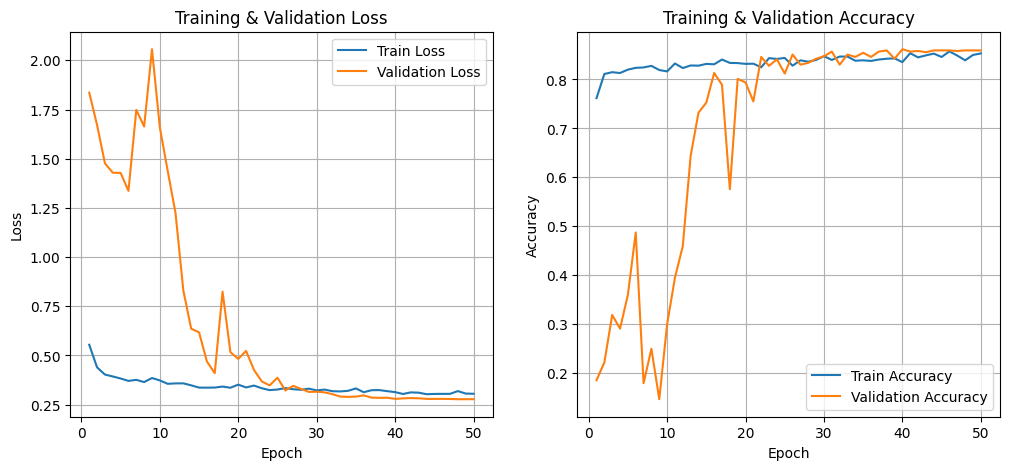

In [ ]:
plot_training_curves(metrics)

In [ ]:
from sklearn.metrics import classification_report

labels = ['cheap', 'averege', 'expensive']
preds, targets = get_predictions(classifier_unbalanced, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.75      0.81      0.78       112
     averege       0.92      0.90      0.91       599
   expensive       0.77      0.78      0.78       114

    accuracy                           0.88       825
   macro avg       0.81      0.83      0.82       825
weighted avg       0.88      0.88      0.88       825



In [ ]:
report = classification_report_imbalanced(targets, preds, target_names = labels)
print(report)

                   pre       rec       spe        f1       geo       iba       sup

      cheap       0.75      0.81      0.96      0.78      0.88      0.77       112
    averege       0.92      0.90      0.80      0.91      0.85      0.73       599
  expensive       0.77      0.78      0.96      0.78      0.87      0.74       114

avg / total       0.88      0.88      0.84      0.88      0.86      0.73       825



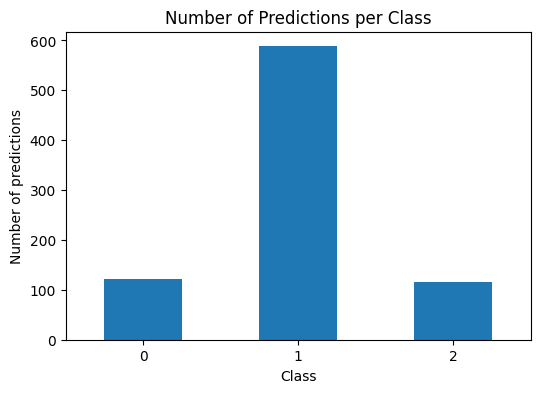

In [ ]:
pred_counts = pd.Series(preds).value_counts().sort_index()

pred_counts.plot(kind="bar", figsize=(6,4))
plt.xlabel("Class")
plt.ylabel("Number of predictions")
plt.title("Number of Predictions per Class")
plt.xticks(rotation=0)
plt.show()

**Wnioski:**

Model uczony na niezbalansowanym zbiorze uzyskał największe accuracy (0.88), co jest prawdopodobnie spowodowane tym, że większość w zbiorze testowym stanowi klasa 'average'. Na podstawie F1 i recall można stwierdzić, że gorzej wykrywa klasy mniejszościowe.

## Ważenie przykładów

In [ ]:
# Weights to counter the unbalanced dataset
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
weights_sqrt = np.sqrt(weights)
weights_manual = np.array([1.2, 1, 1.2])

weights, weights_sqrt, weights_manual

(array([2.4460261 , 0.45944742, 2.41169591]),
 array([1.56397765, 0.67782551, 1.55296359]),
 array([1.2, 1. , 1.2]))

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

classifier_weights = Classifier(n_features=num_features, n_classes=num_classes, hidden_1=128, hidden_2=64)
classifier_weights.to(device)

num_epochs = 70

class_weights = torch.FloatTensor(weights_sqrt).cuda()
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(classifier_weights.parameters(), lr=1e-2, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)


metrics = train(classifier_weights, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)


torch.save(classifier_weights.state_dict(), 'classifier_weights.pth')

100%|██████████| 20/20 [00:00<00:00, 237.60it/s]


(Epoch 1/[train]) Loss:	0.609   Accuracy: 0.747   lr: 0.01


100%|██████████| 7/7 [00:00<00:00, 347.79it/s]


(Epoch 1/[val]) Loss:	3.078   Accuracy: 0.170   lr: 0.01


100%|██████████| 20/20 [00:00<00:00, 230.24it/s]


...

(Epoch 69/[val]) Loss:	0.305   Accuracy: 0.830   lr: 3.0108401493780873e-05


100%|██████████| 20/20 [00:00<00:00, 233.06it/s]


(Epoch 70/[train]) Loss:	0.337   Accuracy: 0.827   lr: 1.5029632626133633e-05


100%|██████████| 7/7 [00:00<00:00, 297.58it/s]

(Epoch 70/[val]) Loss:	0.305   Accuracy: 0.824   lr: 1.5029632626133633e-05


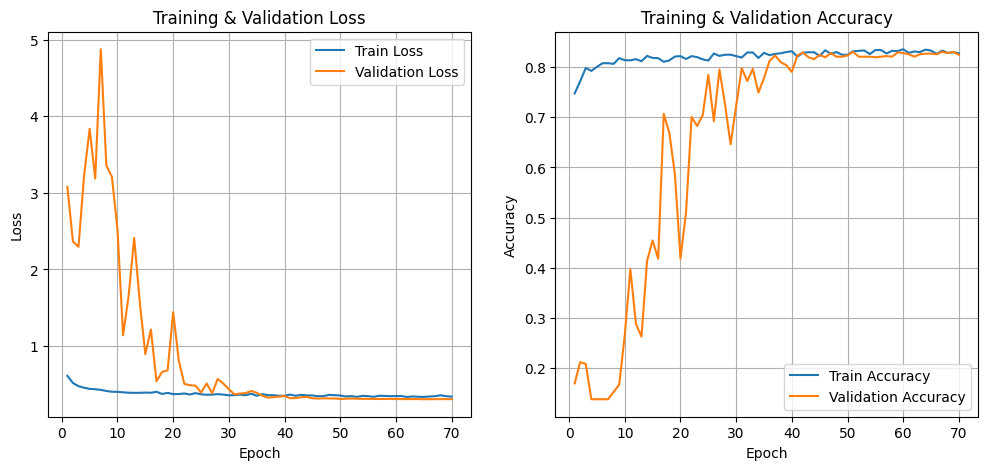

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(classifier_weights, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.63      0.99      0.77       112
     averege       0.97      0.83      0.89       599
   expensive       0.72      0.86      0.78       114

    accuracy                           0.85       825
   macro avg       0.77      0.89      0.82       825
weighted avg       0.89      0.85      0.86       825



In [ ]:
report = classification_report_imbalanced(targets, preds, target_names = labels)
print(report)

                   pre       rec       spe        f1       geo       iba       sup

      cheap       0.63      0.99      0.91      0.77      0.95      0.91       112
    averege       0.97      0.83      0.92      0.89      0.88      0.76       599
  expensive       0.72      0.86      0.95      0.78      0.90      0.81       114

avg / total       0.89      0.85      0.93      0.86      0.89      0.79       825



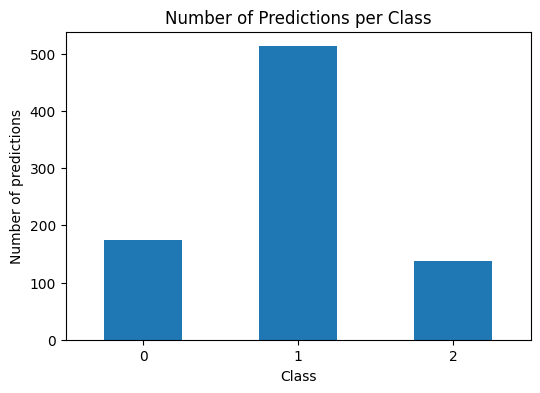

In [ ]:
pred_counts = pd.Series(preds).value_counts().sort_index()

pred_counts.plot(kind="bar", figsize=(6,4))
plt.xlabel("Class")
plt.ylabel("Number of predictions")
plt.title("Number of Predictions per Class")
plt.xticks(rotation=0)
plt.show()

**Wnioski:**

Średnie F1 jest porównywalna do wcześniejszego modelu, lecz lekko zmalała dla klasy 'average'. Ogólna dokładność jest mniejsza, ale recall dla klas mniejszościowych jest lepsze.

## Resampling

### Oversampling

In [ ]:
over_sampler = RandomOverSampler(random_state=SEED)
X_os, y_os = over_sampler.fit_resample(X_train, y_train)

In [ ]:
X_train_tensor = torch.tensor(X_os.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_os.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = data.TensorDataset(X_test_tensor, y_test_tensor)

datasets = {
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}

In [ ]:
BATCH_SIZE = 128

dataloaders = {split: data.DataLoader(datasets[split], batch_size=BATCH_SIZE, shuffle=split=='train', num_workers=0) for split in datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

classifier_os = Classifier(n_features=num_features, n_classes=num_classes, hidden_1=128, hidden_2=64)
classifier_os.to(device)

num_epochs = 70

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier_os.parameters(), lr=1e-2, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(classifier_os, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)


torch.save(classifier_os.state_dict(), 'classifier_over_sampling.pth')

100%|██████████| 43/43 [00:00<00:00, 160.78it/s]


(Epoch 1/[train]) Loss:	0.531   Accuracy: 0.781   lr: 0.01


100%|██████████| 7/7 [00:00<00:00, 238.97it/s]


(Epoch 1/[val]) Loss:	3.290   Accuracy: 0.170   lr: 0.01


100%|██████████| 43/43 [00:00<00:00, 171.07it/s]


...

(Epoch 69/[val]) Loss:	0.401   Accuracy: 0.794   lr: 3.0108401493780873e-05


100%|██████████| 43/43 [00:00<00:00, 236.43it/s]


(Epoch 70/[train]) Loss:	0.287   Accuracy: 0.886   lr: 1.5029632626133633e-05


100%|██████████| 7/7 [00:00<00:00, 262.47it/s]

(Epoch 70/[val]) Loss:	0.401   Accuracy: 0.794   lr: 1.5029632626133633e-05


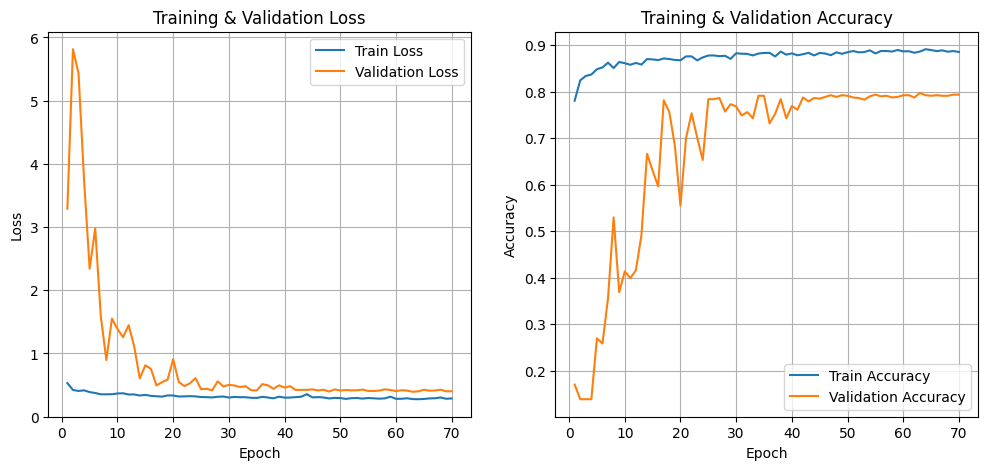

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(classifier_os, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.62      0.99      0.77       112
     averege       0.98      0.75      0.85       599
   expensive       0.56      0.95      0.71       114

    accuracy                           0.81       825
   macro avg       0.72      0.90      0.77       825
weighted avg       0.88      0.81      0.82       825



In [ ]:
report = classification_report_imbalanced(targets, preds, target_names = labels)
print(report)

                   pre       rec       spe        f1       geo       iba       sup

      cheap       0.62      0.99      0.91      0.77      0.95      0.91       112
    averege       0.98      0.75      0.97      0.85      0.85      0.71       599
  expensive       0.56      0.95      0.88      0.71      0.91      0.84       114

avg / total       0.88      0.81      0.95      0.82      0.87      0.75       825



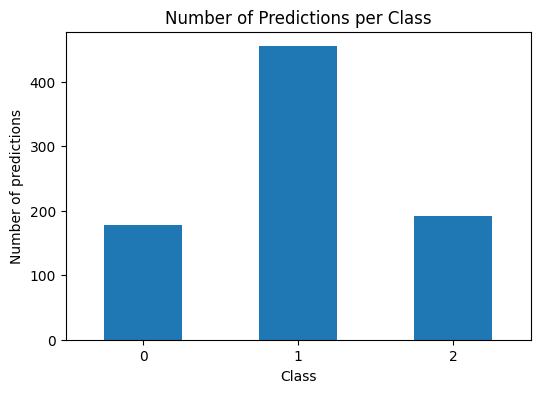

In [ ]:
pred_counts = pd.Series(preds).value_counts().sort_index()

pred_counts.plot(kind="bar", figsize=(6,4))
plt.xlabel("Class")
plt.ylabel("Number of predictions")
plt.title("Number of Predictions per Class")
plt.xticks(rotation=0)
plt.show()

### Undersampling

In [ ]:
under_sampler = RandomUnderSampler(random_state=SEED)
X_us, y_us = under_sampler.fit_resample(X_train, y_train)

In [ ]:
X_train_tensor = torch.tensor(X_us.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_us.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = data.TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = data.TensorDataset(X_test_tensor, y_test_tensor)

datasets = {
    'train': train_dataset,
    'val': val_dataset,
    'test': test_dataset
}

In [ ]:
BATCH_SIZE = 128

dataloaders = {split: data.DataLoader(datasets[split], batch_size=BATCH_SIZE, shuffle=split=='train', num_workers=0) for split in datasets}

In [ ]:
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

classifier_us = Classifier(n_features=num_features, n_classes=num_classes, hidden_1=128, hidden_2=64)
classifier_us.to(device)

num_epochs =  50

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(classifier_us.parameters(), lr=1e-2, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

metrics = train(classifier_us, dataloaders, criterion, optimizer, lr_scheduler, num_epochs)


torch.save(classifier_us.state_dict(), 'classifier_under_sampling.pth')

100%|██████████| 8/8 [00:00<00:00, 223.06it/s]


(Epoch 1/[train]) Loss:	0.704   Accuracy: 0.692   lr: 0.01


100%|██████████| 7/7 [00:00<00:00, 361.60it/s]


(Epoch 1/[val]) Loss:	5.071   Accuracy: 0.138   lr: 0.01


100%|██████████| 8/8 [00:00<00:00, 237.35it/s]


...

(Epoch 49/[val]) Loss:	0.443   Accuracy: 0.778   lr: 4.9387066934183544e-05


100%|██████████| 8/8 [00:00<00:00, 197.34it/s]


(Epoch 50/[train]) Loss:	0.338   Accuracy: 0.849   lr: 1.9856491500783562e-05


100%|██████████| 7/7 [00:00<00:00, 328.68it/s]

(Epoch 50/[val]) Loss:	0.443   Accuracy: 0.777   lr: 1.9856491500783562e-05


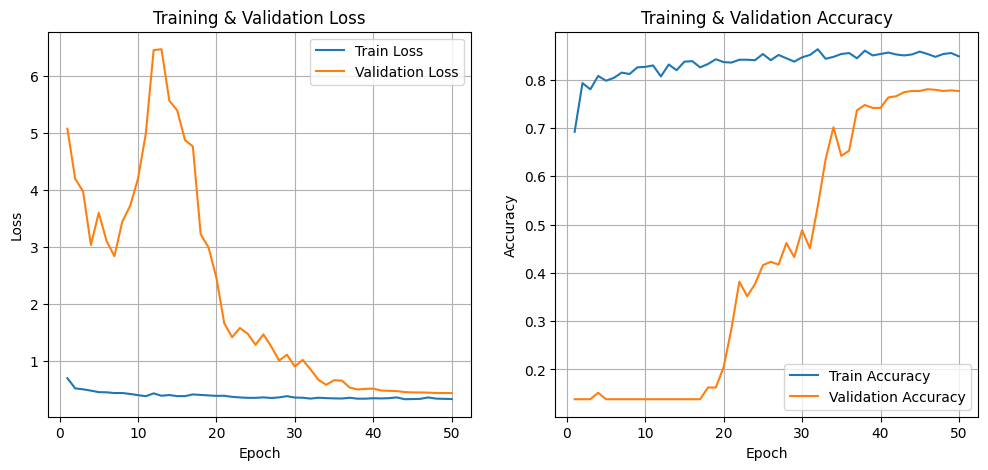

In [ ]:
plot_training_curves(metrics)

In [ ]:
preds, targets = get_predictions(classifier_us, dataloaders["test"], device)

report = classification_report(targets, preds, target_names = labels)
print(report)

              precision    recall  f1-score   support

       cheap       0.59      0.99      0.74       112
     averege       0.98      0.73      0.84       599
   expensive       0.57      0.95      0.71       114

    accuracy                           0.80       825
   macro avg       0.71      0.89      0.76       825
weighted avg       0.87      0.80      0.81       825



In [ ]:
report = classification_report_imbalanced(targets, preds, target_names = labels)
print(report)

                   pre       rec       spe        f1       geo       iba       sup

      cheap       0.59      0.99      0.89      0.74      0.94      0.89       112
    averege       0.98      0.73      0.97      0.84      0.84      0.69       599
  expensive       0.57      0.95      0.88      0.71      0.92      0.84       114

avg / total       0.87      0.80      0.95      0.81      0.87      0.74       825



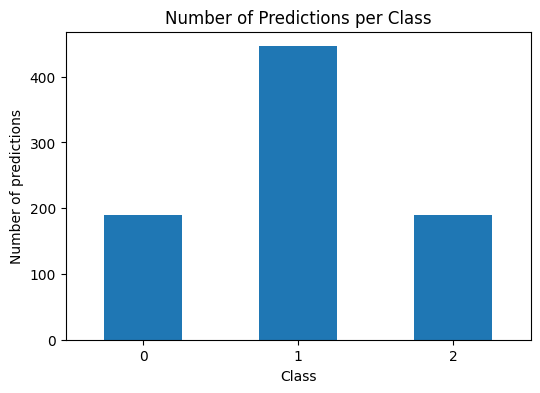

In [ ]:
pred_counts = pd.Series(preds).value_counts().sort_index()

pred_counts.plot(kind="bar", figsize=(6,4))
plt.xlabel("Class")
plt.ylabel("Number of predictions")
plt.title("Number of Predictions per Class")
plt.xticks(rotation=0)
plt.show()

**Wnioski**

Te modele miały najgorszą dokładność, ok. 0.81. Za to recall dla klas mniejszościowych jest tutaj największy, bliski 0.99. Oznacza to, że prawie wszystkie ich przykłady zostały poprawnie wykryte, kosztem spadku precyzji. F1 score dla klasy 'average' jest widocznie mniejsze niż we wcześniejszych modelach.

## Zapisanie predykcji

Ostatecznie wybrałyśmy model używającego ważenie przykładów - mające dosyć wysoką dokładność (0.85), zadowalające średnie F1 score (0.86) oraz wysokie recall dla klas mniejszościowych.

In [ ]:
test_df = pd.read_csv("test_data.csv")

In [ ]:
len(test_df)

1767

In [ ]:
print(test_df["HallwayType"].unique())
print(test_df["HeatingType"].unique())
print(test_df["AptManageType"].unique())
print(test_df["TimeToBusStop"].unique())
print(test_df["TimeToSubway"].unique())
print(test_df["SubwayStation"].unique())

['mixed' 'terraced' 'corridor']
['individual_heating' 'central_heating']
['management_in_trust' 'self_management']
['0~5min' '5min~10min' '10min~15min']
['15min~20min' '0-5min' '5min~10min' '10min~15min' 'no_bus_stop_nearby']
['Myung-duk' 'Banwoldang' 'Bangoge' 'Kyungbuk_uni_hospital'
 'no_subway_nearby' 'Sin-nam' 'Chil-sung-market' 'Daegu']


In [ ]:
test_df.HeatingType = (test_df.HeatingType == "individual_heating").astype(int)
test_df.AptManageType = (test_df.AptManageType == "management_in_trust").astype(int)

one_hot_encoding_columns = ["HallwayType", "TimeToBusStop", "TimeToSubway", "SubwayStation"]
categorical_values = pd.get_dummies(test_df[one_hot_encoding_columns]).astype(int)

In [ ]:
test_df.drop(columns=one_hot_encoding_columns, inplace=True)
test_df.head()

,YearBuilt,Size(sqf),Floor,HeatingType,AptManageType,N_Parkinglot(Ground),N_Parkinglot(Basement),N_manager,N_elevators,N_FacilitiesInApt,N_FacilitiesNearBy(Total),N_SchoolNearBy(Total)
0,1993,914,10,1,1,523.0,536.0,8.0,20.0,4,14.0,17.0
1,2014,907,16,1,1,90.0,1174.0,7.0,20.0,9,14.0,17.0
2,2007,1629,7,1,1,7.0,605.0,5.0,5.0,5,9.0,5.0
3,2005,743,21,1,1,67.0,798.0,6.0,0.0,7,13.0,15.0
4,2006,903,7,1,1,123.0,181.0,3.0,11.0,4,8.0,11.0


In [ ]:
X_eval = pd.concat([test_df, categorical_values], axis=1)

X_eval_tensor = torch.tensor(X_eval.values, dtype=torch.float32).to(device)
eval_dataset = data.TensorDataset(X_eval_tensor)
eval_loader = data.DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
classifier_weights.eval()
predictions = []

with torch.inference_mode():
    for (X_batch,) in eval_loader:
        X_batch = X_batch.float()

        logits = classifier_weights(X_batch).squeeze()
        _, preds = torch.max(logits, dim=1)
        predictions.extend(preds.tolist())

In [ ]:
results = pd.DataFrame({
    "prediction": predictions
})

results.size

1767

In [ ]:
results[:10]

,prediction
0,1
1,2
2,2
3,1
4,1
5,2
6,1
7,0
8,1
9,1


In [ ]:
results.value_counts()

,count
prediction,
1,1103
0,395
2,269


In [ ]:
results.to_csv("pred.csv", index=False, header=False)